{'topic': '猴子', 'poem': '', 'joke': '这是一个关于猴子的冷笑话，希望你喜欢：\n\n---\n\n一只猴子走进了一家酒吧，跳到吧台上，对着酒保说：“给我来一杯香蕉马提尼。”\n\n酒保惊讶地看着它，说：“哇，你会说话？而且还会点酒？”\n\n猴子翻了个白眼，不耐烦地说：“别大惊小怪了。隔壁桌那只大象还会用长鼻子弹钢琴呢，快把我的酒拿来。”\n\n酒保赶紧调好酒递过去，然后好奇地问：“那……你为什么不找份正经工作，比如说去马戏团？”\n\n猴子喝了一口酒，慢悠悠地说：“马戏团？拜托，那都是给**没受过教育**的动物干的。我可是有正经工作的——我是动物园里的**解说员**。”\n\n酒保更好奇了：“解说员？解说什么？”\n\n猴子叹了口气，指了指自己说：“跟游客解释，我们猴子**并不是**从人类进化来的。”', 'ci_poem': '好的，这里有几个关于猴子的词，或灵动、或深刻，供您参考：\n\n**1. 七分灵动，三分顽劣，一分赤子之心。**\n*（评述：这不仅是形容猴子，也是在说一种鲜活的生命力。）*\n\n**2. 树梢上的风，藤蔓间的影，跳跃时散落一地的月光。**\n*（描绘：侧重于猴子在自然中轻盈、迅捷的动态美感。）*\n\n**3. 猢狲解带，顽石点头。**\n*（禅意：前半句写猴子卸下束缚的自在，后半句借顽石拟人，烘托氛围。）*\n\n**4. 灵长之智，芥子之躯，敢向天宫问不平。**\n*（典故：暗指孙悟空，赞美其勇气与智慧，恰如“身如芥子，心藏须弥”。）*\n\n**5. 一树春山，几声猿啼，惊落半盏茶烟。**\n*（意境：将猴子的叫声融入山水茶意之中，更显清幽。）*\n\n---\n\n如果您需要，我可以再为您写一个更具体场景的词，比如“黄昏时独坐的猴”或“顽童看猴”的片段。', 'content_type': '笑话'}


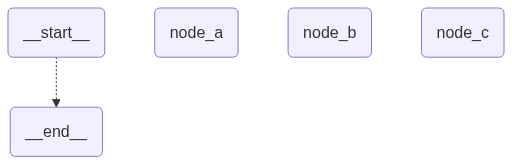

Done


In [4]:
from aiohttp.web_fileresponse import content_type
from isort import literal
# from langgraph.constants import END, START
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Sequence
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem: str
    content_type: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}的诗"]).content
    return {
        "poem": poem,
        # "topic": state["topic"],
        # "joke": state["joke"],
        # "ci_poem": state["ci_poem"],
    }

def node_b(state: OverAllState) -> OverAllState:
    joke  = model.invoke([f"写一个关于{state['topic']}的笑话"]).content
    return {
        "joke": joke,
        # "topic": state["topic"],
        # "poem": state["poem"],
        # "ci_poem": state["ci_poem"],
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem  = model.invoke([f"写一个关于{state['topic']}的词"]).content
    return {
        "ci_poem": ci_poem,
        # "joke": state["joke"],
        # "topic": state["topic"],
        # "poem": state["poem"],
    }

def my_route(state: OverAllState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a", "node_c"]
    else :
        return ["node_b", "node_c"]




builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)  # 显式命名节点
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_conditional_edges(START, my_route)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)



graph = builder.compile()
res = graph.invoke({"topic": "猴子","poem":"", "joke":"", "content_type":"笑话"})

print(f"{res}")
display(graph)
print("Done")